## Air Quality Index (AQI) Analysis of Indian Cities
### Pollution Recovery Asymmetry — Do Indian Cities Clean Up as Fast as They Get Polluted?



### Step 1: Import Libraries & Dataset

In [ ]:
# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
df = pd.read_csv("aqi_pollution_trends_india.csv")

# 3. Display first few rows
df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


### Step 2: Exploratory Data Analysis (EDA)

In [11]:
# 1. Check shape of dataset
print("Shape of dataset:", df.shape)

# 2. Check column names
print("Columns:", df.columns)

# 3. Check data types and info
df.info()

# 4. Summary statistics
df.describe()

# 5. Check missing values
print("Missing values:\n", df.isnull().sum())

Shape of dataset: (235785, 9)
Columns: Index(['date', 'state', 'area', 'number_of_monitoring_stations',
       'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit',
       'note'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  object 
 1   state                          235785 non-null  object 
 2   area                           235785 non-null  object 
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  object 
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  object 
 7   unit                           235785 non-null  object 
 8   note                           0 non-null       float64
dty

In [12]:
# Convert date column properly
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check if conversion worked
print(df['date'].dtype)

datetime64[ns]


C:\Users\PREM\AppData\Local\Temp\ipykernel_10880\97105754.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [13]:
# Make sure date is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['date'])

# Create month column
df['month'] = df['date'].dt.month

# Step 3: Data Visualization

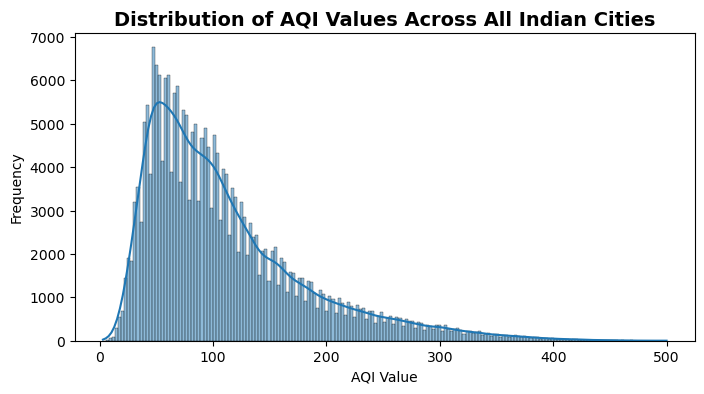

In [14]:
# 1. AQI Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['aqi_value'], kde=True)
plt.title("Distribution of AQI Values Across All Indian Cities", fontsize=14, weight='bold')
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

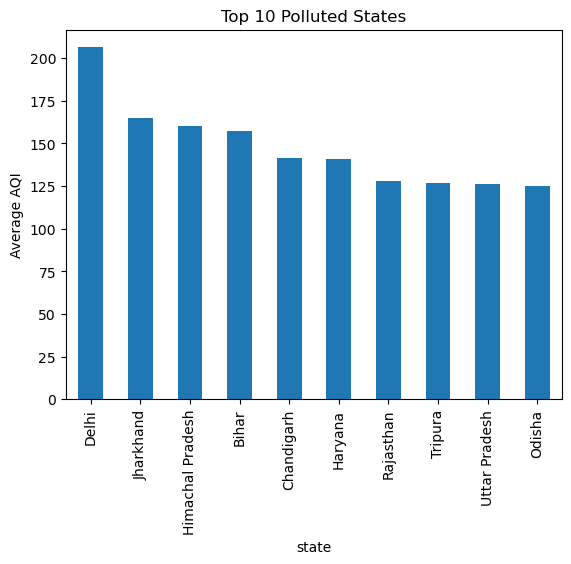

In [15]:
# 2. Top polluted states
plt.figure()
df.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Polluted States")
plt.ylabel("Average AQI")
plt.show()

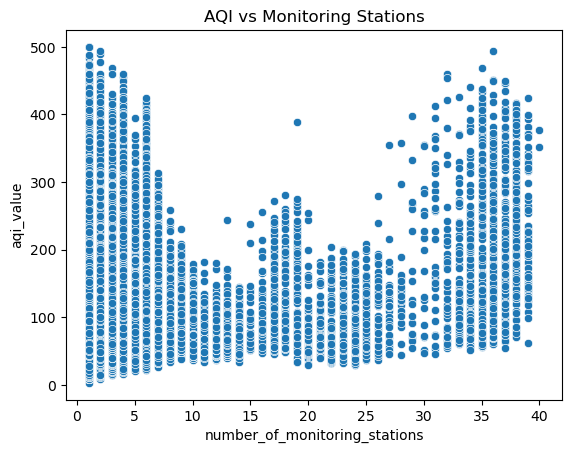

Insight: Weak relationship between AQI and number of stations.


In [16]:
plt.figure()
sns.scatterplot(
    x='number_of_monitoring_stations',
    y='aqi_value',
    data=df
)

plt.title("AQI vs Monitoring Stations")
plt.show()

print("Insight: Weak relationship between AQI and number of stations.")

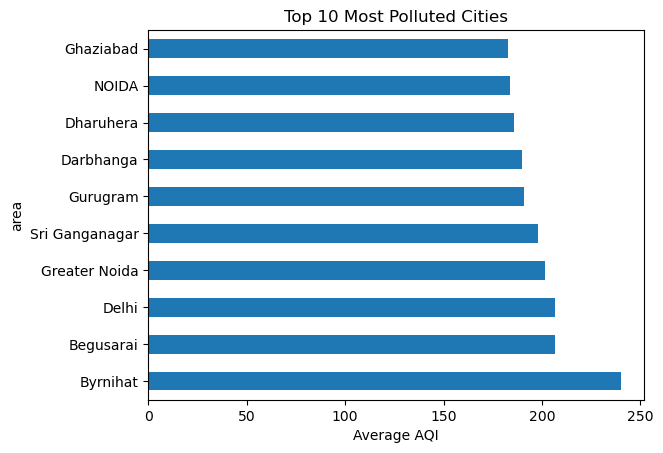

Insight: Certain cities consistently show higher AQI levels.


In [17]:
#4. Top polluted cities
plt.figure()
df.groupby('area')['aqi_value'].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average AQI")
plt.show()

print("Insight: Certain cities consistently show higher AQI levels.")

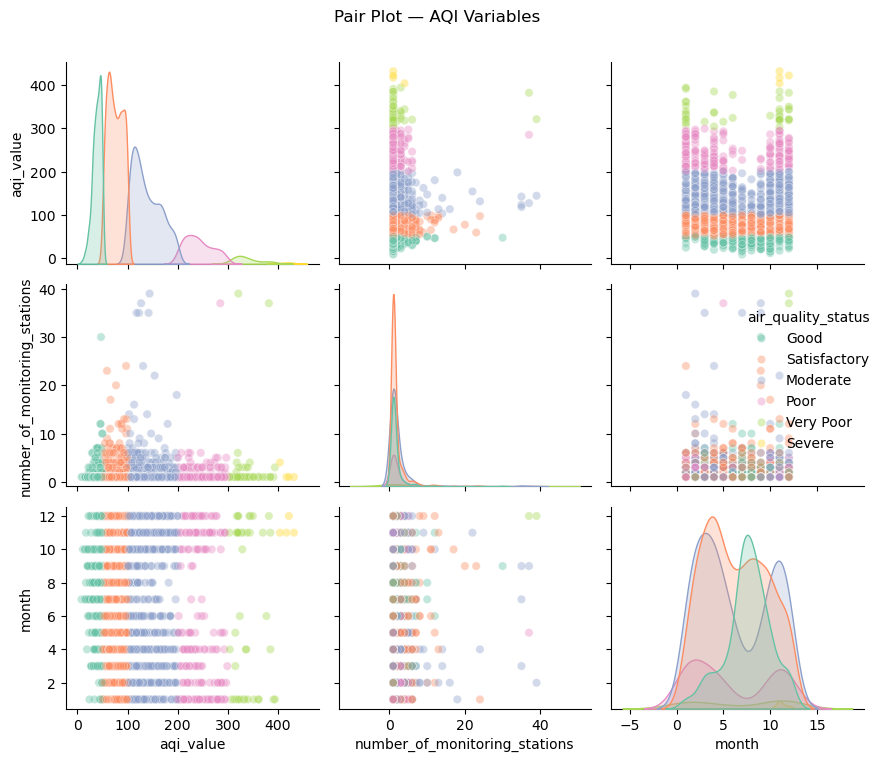

In [31]:
#Pair Plot
# We use a sample of 2000 rows for speed
sample = df[['aqi_value', 'number_of_monitoring_stations', 'month', 'air_quality_status']].sample(
    2000, random_state=42
)

sns.pairplot(sample, hue='air_quality_status',
             vars=['aqi_value', 'number_of_monitoring_stations', 'month'],
             palette='Set2', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot — AQI Variables', y=1.01)
plt.tight_layout()
plt.show()

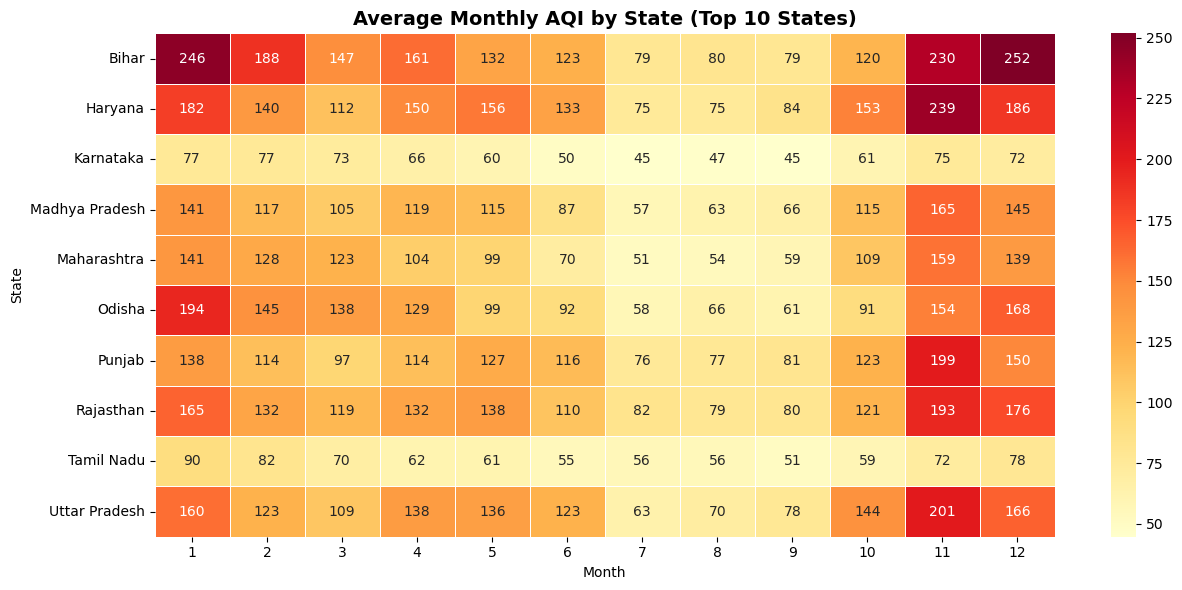

Insight: Heatmap shows how AQI varies across states and months, highlighting seasonal patterns.


In [19]:
#correlation Heatmap

# Select top 10 states
top_states = df['state'].value_counts().head(10).index

# Create pivot table
heatmap_data = df[df['state'].isin(top_states)].pivot_table(
    index='state',
    columns='month',
    values='aqi_value',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(13,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4
)

plt.title('Average Monthly AQI by State (Top 10 States)', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('State')

plt.tight_layout()
plt.show()

print("Insight: Heatmap shows how AQI varies across states and months, highlighting seasonal patterns.")

In [20]:
print("Insight: AQI shows variation over time and across states.")
print("Insight: Weak correlation between AQI and monitoring stations.")

Insight: AQI shows variation over time and across states.
Insight: Weak correlation between AQI and monitoring stations.


### Step 4: Data Cleaning

In [22]:
# 1. Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Drop unnecessary columns
df = df.drop(columns=['unit', 'note'], errors='ignore')

# 4. Final check
print("Cleaned data shape:", df.shape)

Cleaned data shape: (235785, 8)


### Step 5: Data Preparation

In [23]:
# 1. Extract useful features from date
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# 2. Define features and target
X = df[['state', 'area', 'number_of_monitoring_stations', 'month', 'year']]
y = df['aqi_value']

# 3. Convert categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# 4. Check final features
print("Feature columns:", X.columns)

Feature columns: Index(['number_of_monitoring_stations', 'month', 'year',
       'state_Andhra Pradesh', 'state_Arunachal Pradesh', 'state_Assam',
       'state_Bihar', 'state_Chandigarh', 'state_Chhattisgarh', 'state_Delhi',
       ...
       'area_Vatva', 'area_Vellore', 'area_Vijayapura', 'area_Vijayawada',
       'area_Virar', 'area_Virudhunagar', 'area_Visakhapatnam',
       'area_Vrindavan', 'area_Yadgir', 'area_Yamunanagar'],
      dtype='object', length=324)


### Step 6: Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (188628, 324)
Testing size: (47157, 324)


### Model Building

#### 7.1 Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


### 7.2 Model Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 44.49959393445165
MSE: 3707.382316425771
R2 Score: 0.2834909592609892


In [27]:
print("\nModel Insight (Regression):")

print("The model predicts AQI using location and time features.")

print("MAE shows average prediction error, while MSE highlights larger errors.")

print("R2 score is low, meaning the model explains only a small part of AQI variation.")

print("Conclusion: AQI depends on additional factors like weather and human activities,")
print("so the model captures general trends but not exact values.")


Model Insight (Regression):
The model predicts AQI using location and time features.
MAE shows average prediction error, while MSE highlights larger errors.
R2 score is low, meaning the model explains only a small part of AQI variation.
Conclusion: AQI depends on additional factors like weather and human activities,
so the model captures general trends but not exact values.


### 8.1 Classification Model (Logistic Regression)

In [28]:
# 1. Create classification target (0 = Clean, 1 = Polluted)
df['pollution_flag'] = (df['aqi_value'] > 150).astype(int)

# 2. Define features and target
X_clf = X
y_clf = df['pollution_flag']

# 3. Split dataset
from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 4. Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)

# 5. Predictions
y_pred_c = clf.predict(X_test_c)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 8.2 Model Evaluation

In [29]:
# 6. Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Classification Results:")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c))
print("Recall:", recall_score(y_test_c, y_pred_c))
print("F1 Score:", f1_score(y_test_c, y_pred_c))

Classification Results:
Accuracy: 0.7866912653476684
Precision: 0.562255859375
Recall: 0.21790140978332861
F1 Score: 0.31408114558472555


In [30]:
print("\nModel Insight (Classification):")

print("The model classifies whether AQI is polluted or not.")

print("Accuracy, Precision, Recall, and F1-score show moderate performance.")

print("Conclusion: The model can identify pollution levels to some extent,")
print("but accuracy is limited due to missing environmental factors.")


Model Insight (Classification):
The model classifies whether AQI is polluted or not.
Accuracy, Precision, Recall, and F1-score show moderate performance.
Conclusion: The model can identify pollution levels to some extent,
but accuracy is limited due to missing environmental factors.


## Final Analysis and Conclusion

AQI varies across states and shows clear seasonal patterns, especially higher pollution in winter.

The regression model captures general AQI trends but has limited accuracy due to missing external factors.

The classification model performs moderately in identifying polluted conditions.

Overall, AQI prediction is complex and depends on factors beyond the given dataset.